# Task 4.8 — Predict HAI Durability for H3N2 A/Massachusetts/18/2022 (D365)

**4.8 predict durability of antibody response - H3N2 A/Massachusetts/18/2022 (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Post-vac HAI / Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 365

---

## Design notes

**Proxy target:** The target strain (H3N2 A/Massachusetts/18/2022) is absent from the training data.
We approximate it by averaging the Day 365 HAI titers of all other H3N2 strains present in the dataset.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale.
Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
TARGET_COL = 'H3N2_proxy_d365'  # proxy: target strain absent from training data
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [2]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../../cleaned_data'
SUBMISSION_PATH = '../../automl_submission'

In [3]:
import io
import os
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — proxy target

The target strain is absent from the training set. We create a proxy by averaging all H3N2 Day 365 HAI titers.
Rows are filtered to those with a valid proxy target, then all-null columns are removed on the filtered subset.
The `_d28`/`_d365` columns are excluded from features at training time to prevent leakage.

In [5]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Raw shape: {df.shape}')

Raw shape: (3757, 110063)


In [6]:
# Create proxy target: row-wise average of all H3N2 d365 HAI strains
h3n2_d365_cols = [c for c in df.columns if c.startswith('HAI_') and 'H3N2' in c and c.endswith('_d365')]
df[TARGET_COL] = df[h3n2_d365_cols].mean(axis=1)
print(f'Proxy target averaged from {len(h3n2_d365_cols)} H3N2 d365 strains')

Proxy target averaged from 23 H3N2 d365 strains


In [7]:
# Filter to rows with a valid proxy target first
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Rows with valid proxy target: {len(df)}')

# Drop all-null columns on the filtered subset
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns → {df.shape[1]} remaining')

# Drop columns with 75%+ missing values
before = df.shape[1]
df = df.loc[:, df.notna().mean() >= 0.25]
print(f'Dropped {before - df.shape[1]} columns with ≥75% missing → {df.shape[1]} remaining')

Rows with valid proxy target: 990
Dropped 49807 all-null columns → 60257 remaining
Dropped 60184 columns with ≥75% missing → 73 remaining


In [8]:
print(f'Shape: {df.shape}')
print(f'Target stats:\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')
print(f'\nMissing per column (top 10):\n{df.isna().sum().sort_values(ascending=False).head(10)}')

Shape: (990, 73)
Target stats:
count    990.000000
mean       4.820585
std        1.583616
min        2.321928
25%        3.521928
50%        4.721928
75%        5.914785
max       10.488595
Name: H3N2_proxy_d365, dtype: float64

dtype counts:
float64    68
object      5
Name: count, dtype: int64

Missing per column (top 10):
HAI_Anc B/Lee/1940_d28                674
HAI_Anc B/Lee/1940_d0                 674
HAI_H3N2 A/Tasmania/503/2020_d28      509
HAI_H1N1 A/Victoria/2570/2019_d28     509
HAI_H3N2 A/Darwin/9/2021_d28          509
HAI_Vic B/Austria/1359417/2021_d28    509
HAI_H1N1 A/Victoria/2570/2019_d0      498
HAI_H3N2 A/Darwin/9/2021_d365         498
HAI_H3N2 A/Darwin/9/2021_d0           498
HAI_H3N2 A/Tasmania/503/2020_d365     498
dtype: int64


---
## AutoML Setup

In [9]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)
  Starting server from C:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\arvin\AppData\Local\Temp\tmpmi8enwzj
  JVM stdout: C:\Users\arvin\AppData\Local\Temp\tmpmi8enwzj\h2o_arvin_started_from_python.out
  JVM stderr: C:\Users\arvin\AppData\Local\Temp\tmpmi8enwzj\h2o_arvin_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_arvin_2rm39o
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.920 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [10]:
print(f'Converting to H2O: {df.shape[0]} rows × {df.shape[1]} columns')
data = h2o.H2OFrame(df)
print(f'H2OFrame shape: {data.shape}')

Converting to H2O: 990 rows × 73 columns
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (990, 73)


---
## AutoML Training

In [11]:
# Features: everything available at d0/d7 — exclude all d28/d365 targets and participant_id
x = [c for c in data.columns
     if not c.endswith('_d28') and not c.endswith('_d365')
     and c != 'participant_id']
y = TARGET_COL

train = data[data[y].isna() == 0]
print(f'Training samples: {train.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=train)
print('Training complete.')

Training samples: 990  |  Features: 30
Training complete.


In [12]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                     rmse       mse       mae     rmsle    mean_residual_deviance
StackedEnsemble_BestOfFamily_1_AutoML_1_20260509_155619  0.796087  0.633755  0.600758  0.142166                  0.633755
StackedEnsemble_AllModels_1_AutoML_1_20260509_155619     0.798846  0.638155  0.602499  0.142462                  0.638155
GLM_1_AutoML_1_20260509_155619                           0.807049  0.651327  0.613695  0.14482                   0.651327
GBM_grid_1_AutoML_1_20260509_155619_model_1              0.815116  0.664414  0.621449  0.145553                  0.664414
DRF_1_AutoML_1_20260509_155619                           0.824897  0.680454  0.626641  0.146583                  0.680454
GBM_3_AutoML_1_20260509_155619                           0.834551  0.696476  0.633739  0.148809                  0.696476
GBM_2_AutoML_1_20260509_155619                           0.835287  0.697704  0.635685  0.149176                  0.697704
GBM_1_AutoML_1_20260509_

In [13]:
# Stacked Ensembles don't store CV predictions — fall back to best base model if needed
model = aml.leader
if model.cross_validation_holdout_predictions() is None:
    for m_id in aml.leaderboard['model_id'].as_data_frame()['model_id']:
        m = h2o.get_model(m_id)
        if m.cross_validation_holdout_predictions() is not None:
            model = m
            break

cv_preds = model.cross_validation_holdout_predictions().as_data_frame()['predict']
actuals = train[y].as_data_frame()[y]
rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.8 — Spearman (5-fold CV): {rho:.3f}  (p={pval:.4f})')
print(f'Model used for eval: {model.model_id}')

Task 4.8 — Spearman (5-fold CV): 0.851  (p=0.0000)
Model used for eval: GLM_1_AutoML_1_20260509_155619


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dat

Leader model: StackedEnsemble_BestOfFamily_1_AutoML_1_20260509_155619
Varimp model: GLM_1_AutoML_1_20260509_155619


,variable,relative_importance,scaled_importance,percentage
0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,0.461754,1.000000,0.065382
1,HAI_H3N2 A/Tasmania/503/2020_d0.2.321928094887362,0.336454,0.728644,0.047640
2,HAI_H3N2 A/South Australia/34/2019_d0,0.329261,0.713066,0.046622
3,HAI_H3N2 A/Panama/2007/1999_d0,0.269349,0.583318,0.038139
4,HAI_H3N2 A/Darwin/9/2021_d0.2.321928094887362,0.260807,0.564818,0.036929
5,HAI_H3N2 A/Tasmania/503/2020_d0.8.321928094887362,0.237310,0.513932,0.033602
6,HAI_H3N2 A/Switzerland/9715293/2013_d0,0.227047,0.491705,0.032149
7,HAI_H3N2 A/Tasmania/503/2020_d0.7.321928094887363,0.225775,0.488951,0.031969
8,HAI_H3N2 A/Tasmania/503/2020_d0.6.321928094887363,0.224430,0.486037,0.031778
9,HAI_H3N2 A/Texas/50/2012_d0,0.209757,0.454261,0.029701


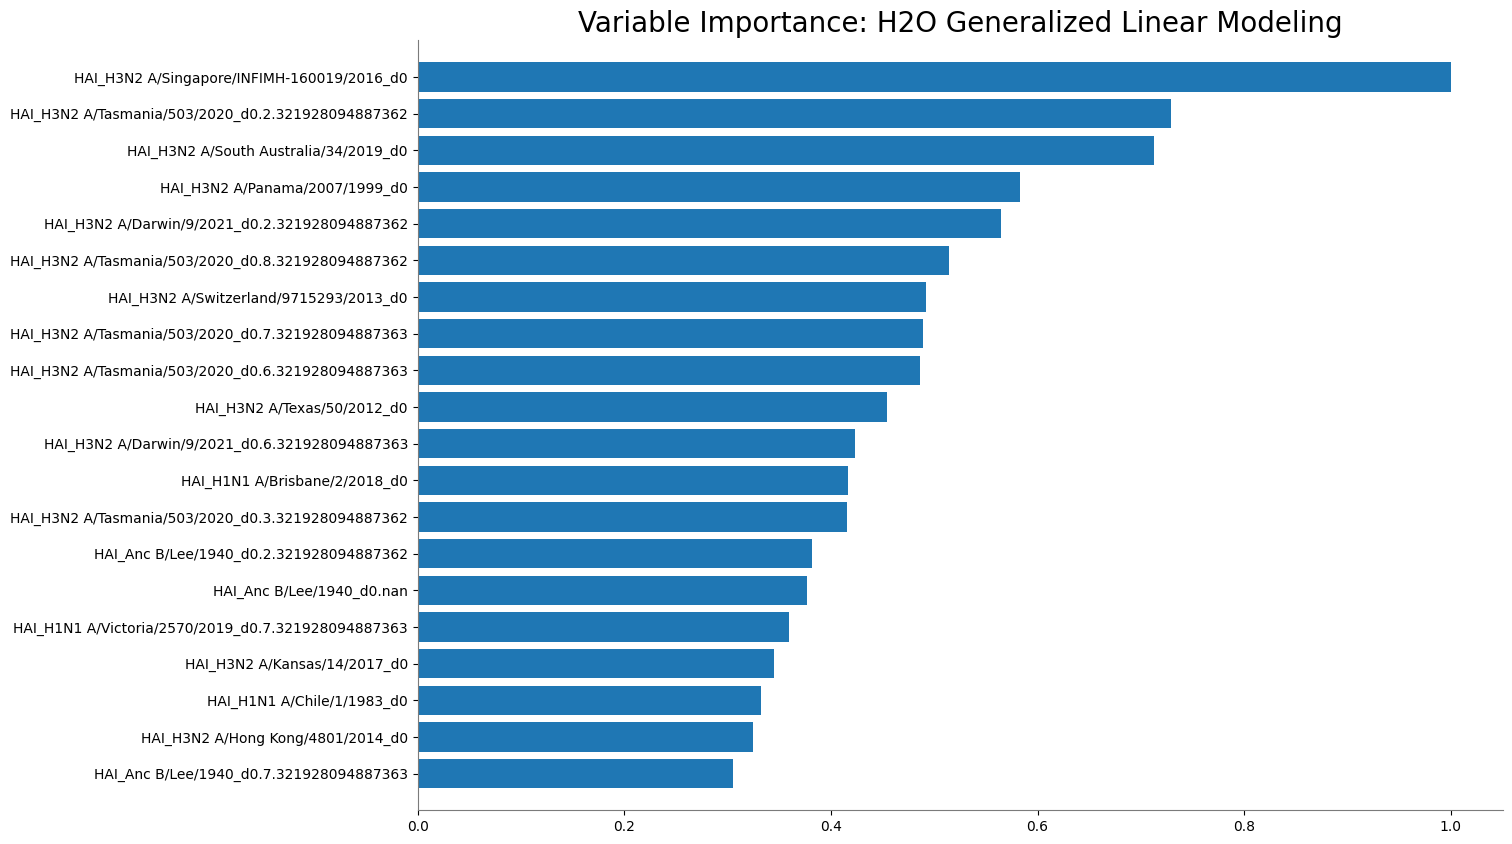

<Figure size 640x480 with 0 Axes>

In [14]:
print(f'Leader model: {aml.leader.model_id}')
print(f'Varimp model: {model.model_id}')
varimp = model.varimp(use_pandas=True)
display(varimp.head(20))
model.varimp_plot(num_of_features=20)

In [15]:
challenge_hf = h2o.H2OFrame(challenge_data)

# Align column types with training frame to avoid type mismatch errors
for col in challenge_hf.columns:
    if col in data.columns:
        train_type = data[col].types[col]
        test_type = challenge_hf[col].types[col]
        if train_type != test_type:
            if train_type == 'enum':
                challenge_hf[col] = challenge_hf[col].ascharacter().asfactor()
            else:
                challenge_hf[col] = challenge_hf[col].asnumeric()

y_pred = aml.leader.predict(challenge_hf).as_data_frame()['predict']

os.makedirs(SUBMISSION_PATH, exist_ok=True)
results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.8': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_8.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.8
0,2024_UGA.ID_077,22.814119
1,2024_UGA.ID_086,13.588760
2,2024_UGA.ID_128,146.518098
3,2024_UGA.ID_170,28.074269
4,2024_UGA.ID_179,19.799485
5,2024_UGA.ID_215,85.064056
6,2024_UGA.ID_219,15.517618
7,2024_UGA.ID_275,13.047073
8,2024_UGA.ID_295,16.203017
9,2024_UGA.ID_296,13.234616


In [16]:
h2o.cluster().shutdown()

H2O session _sid_97a3 closed.


---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)

**Target:** Proxy HAI titer for H3N2 A/Massachusetts/18/2022 at D365 (averaged from all available H3N2 d365 strains).
The target strain is absent from the training data; this proxy is our best approximation.

Submission saved to `automl_submission/task_4_8.csv` (raw titer scale via `np.exp2`).